# Monthly distribution of publish dates across a year in the huggingface ccnews corpus

Analysis of subsets of corpus on Huggingface (not the prefiltered one used for this project)

## Imports and Config

In [ ]:
import duckdb
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 20})

YEAR = "2023"

## Setup

In [31]:
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")

urls = [
    r"https://huggingface.co/datasets/stanford-oval/ccnews/resolve/refs%2Fconvert%2Fparquet/" + YEAR + "/partial-train/0000.parquet",
    r"https://huggingface.co/datasets/stanford-oval/ccnews/resolve/refs%2Fconvert%2Fparquet/" + YEAR + "/partial-train/0001.parquet",
   # r"https://huggingface.co/datasets/stanford-oval/ccnews/resolve/refs%2Fconvert%2Fparquet/" + YEAR + "/partial-train/0002.parquet",

]

## SQL Query and printed results

In [32]:
df = con.execute(f"""
    SELECT
        EXTRACT(MONTH FROM CAST(published_date AS TIMESTAMP)) AS month,
        COUNT(*) AS article_count
    FROM read_parquet({urls})
    WHERE EXTRACT(YEAR FROM CAST(published_date AS TIMESTAMP)) = {YEAR}
    GROUP BY month
    ORDER BY month
""").df()
print(df)

    month  article_count
0       1           1106
1       2            785
2       3            559
3       4            888
4       5            764
5       6            542
6       7            508
7       8           2046
8       9            943
9      10           1699
10     11          46030
11     12         923280


## Visualization

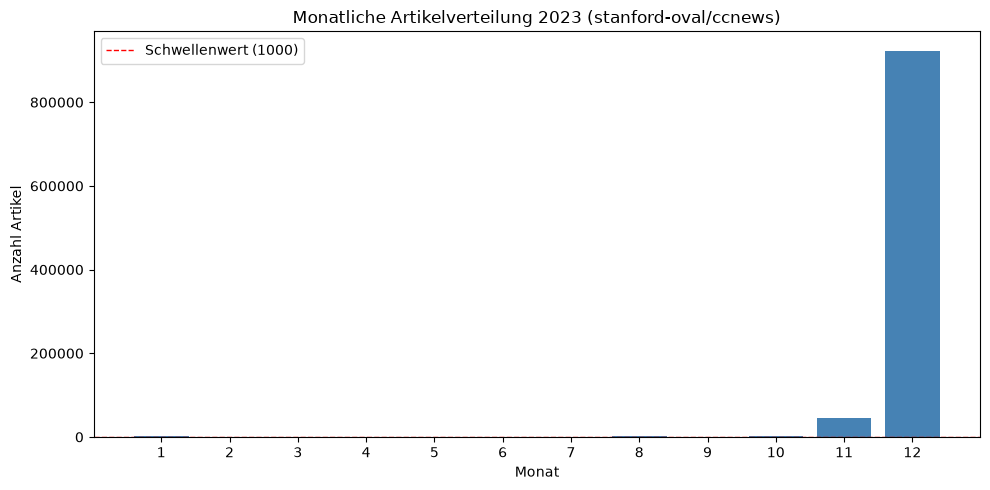

In [ ]:
df_sorted = df.sort_values("month")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_sorted["month"], df_sorted["article_count"], color="steelblue")

ax.set_xlabel("Monat")
ax.set_ylabel("Anzahl Artikel")
ax.set_title("Monatliche Artikelverteilung " + YEAR + " (stanford-oval/ccnews)")
ax.set_xticks(range(1, 13))

DENSITY_THRESHOLD = 1000
ax.axhline(DENSITY_THRESHOLD, color="red", linestyle="--", linewidth=1,
           label=f"Schwellenwert ({DENSITY_THRESHOLD})")
ax.legend()

plt.tight_layout()
plt.savefig("monthly_distribution_2024.png", dpi=150)
plt.show()